# Генерация синтетических данных: Foundation + Morphing + Physics
Block Bootstrapping + Global Magnitude Warping + Poisson Noise.
Подход сохраняет амплитуду пиков, календарные паттерны (для TFT) и пространственную корреляцию графа (для GAT).

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import os, gc, warnings, zipfile, re, pickle
from scipy.interpolate import CubicSpline

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams.update({'figure.figsize': (16, 5), 'font.size': 11})

## 1. Загрузка и подготовка

In [2]:
import gdown
if not os.path.exists('data.zip'):
    gdown.download('https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM', 'data.zip', quiet=False)

DATA_DIR = './data/'
if not os.path.exists(f'{DATA_DIR}PASS_ALL_202503242210.csv'):
    with zipfile.ZipFile('/kaggle/working/data.zip', 'r') as z: z.extractall(DATA_DIR)
    with zipfile.ZipFile('/kaggle/working/data/Метро НБС/pass_10-160324.zip', 'r') as z: z.extractall(DATA_DIR)

Downloading...
From (original): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM
From (redirected): https://drive.google.com/uc?id=1resyBioT2TJTZdLVfuEZdk8PvJAbK5GM&confirm=t&uuid=8d1cda5c-24bc-4f6a-845c-b4e50bbe316d
To: /kaggle/working/data.zip
100%|██████████| 2.51G/2.51G [00:18<00:00, 137MB/s] 


In [3]:
ref_places = pd.read_csv(f'{DATA_DIR}REF_PSG_PLACES_202503251822.csv', sep=';')
ref_routes = pd.read_csv(f'{DATA_DIR}REF_TRANSPORT_WAY_202503251803.csv', sep=';')

os.makedirs('./eda_output', exist_ok=True)
parquet_path = './eda_output/hourly.parquet'

if os.path.exists(parquet_path):
    hourly = pd.read_parquet(parquet_path)
else:
    USE_COLS = ['TRAN_DATE','PLACE_ID','TRANSPORT_TYPE_ID','BUS_RT_NO','IS_FAIL','CRD_NO']
    GROUP_KEYS = ['date_hour','PLACE_ID','TRANSPORT_TYPE_ID','BUS_RT_NO']
    CHUNK = 3_000_000
    agg_parts, n_total = [], 0
    reader = pd.read_csv(f'{DATA_DIR}PASS_ALL_202503242210.csv', sep=';', usecols=USE_COLS, parse_dates=['TRAN_DATE'], chunksize=CHUNK, low_memory=False)
    for i, ch in enumerate(reader):
        n_total += len(ch)
        ch = ch[ch['IS_FAIL'] != 1].copy()
        ch['date_hour'] = ch['TRAN_DATE'].dt.floor('h')
        agg = ch.groupby(GROUP_KEYS, dropna=False).agg(pax=('TRAN_DATE','size')).reset_index()
        agg_parts.append(agg)
        del ch, agg; gc.collect()
    hourly = pd.concat(agg_parts, ignore_index=True); del agg_parts; gc.collect()
    hourly = hourly.groupby(GROUP_KEYS, dropna=False).agg(pax=('pax','sum')).reset_index()
    hourly.to_parquet(parquet_path, index=False)

In [4]:
hourly = hourly.merge(ref_places[['PLACE_ID','TYPE_ID','ST_CODE','ST_NAME','IS_TEST']], on='PLACE_ID', how='left')
hourly = hourly[hourly['IS_TEST'] != 1].drop(columns='IS_TEST')
hourly = hourly.merge(ref_routes[['WAY_ID','NAME']].rename(columns={'WAY_ID':'BUS_RT_NO','NAME':'ROUTE_NAME'}), on='BUS_RT_NO', how='left')

def transport_cat(r):
    if pd.notna(r['BUS_RT_NO']): return 'НГПТ'
    if r['TYPE_ID'] == 1: return 'Метро'
    if r['TYPE_ID'] == 15: return 'МЦД'
    return 'Другое'

hourly['tcat'] = hourly.apply(transport_cat, axis=1)
hourly['date_hour'] = pd.to_datetime(hourly['date_hour'])
hourly['hour'] = hourly['date_hour'].dt.hour
hourly['dow'] = hourly['date_hour'].dt.dayofweek

def clean_id(v):
    s = str(v)
    return s[:-2] if s.endswith('.0') else s

def get_obj_id(row):
    if pd.notna(row.get('BUS_RT_NO')): return f"RT_{clean_id(row['BUS_RT_NO'])}"
    if pd.notna(row.get('ST_CODE')): return f"ST_{clean_id(row['ST_CODE'])}"
    return None

hourly['object_id'] = hourly.apply(get_obj_id, axis=1)
hourly = hourly[hourly.object_id.notna()]

In [21]:
transport_stats = hourly.groupby('tcat')['object_id'].nunique().sort_values(ascending=False)

print("=== КОЛИЧЕСТВО УНИКАЛЬНЫХ ОБЪЕКТОВ В HOURLY ===")
print(transport_stats)
print(f"\nИТОГО объектов в данных: {transport_stats.sum()}")


=== КОЛИЧЕСТВО УНИКАЛЬНЫХ ОБЪЕКТОВ В HOURLY ===
tcat
НГПТ     1048
Метро     314
МЦД       297
Name: object_id, dtype: int64

ИТОГО объектов в данных: 1659


## 2. Широкая таблица (часы x станции)
Работаем напрямую с сырыми значениями, без log1p и PCA, чтобы не разрушать амплитуду.

In [5]:
pivot = hourly.groupby(['date_hour','object_id'])['pax'].sum().reset_index()
pivot = pivot.pivot(index='date_hour', columns='object_id', values='pax').fillna(0)

top_objects = pivot.sum().sort_values(ascending=False).head(1500).index
pivot = pivot[top_objects]

real_matrix = pivot.values # (168, 1500)
print(f"Матрица: {real_matrix.shape[0]} часов x {real_matrix.shape[1]} объектов")

Матрица: 168 часов x 1500 объектов


## 3. Формирование блоков (Foundation)
Группируем историю по дням недели (для сохранения нюансов календаря TFT).

In [6]:
n_hours, n_objects = real_matrix.shape
n_days_real = n_hours // 24

# Словарь: {день_недели: [матрицы_24x1500]}
day_blocks = {i: [] for i in range(7)}

for d in range(n_days_real):
    start_idx = d * 24
    end_idx = start_idx + 24
    if end_idx > n_hours: break
    
    day_data = real_matrix[start_idx:end_idx, :] # (24, 1500)
    dow = pivot.index[start_idx].dayofweek
    day_blocks[dow].append(day_data)

# Статистика по блокам
for dow, blocks in day_blocks.items():
    print(f"День недели {dow}: {len(blocks)} блоков")

День недели 0: 1 блоков
День недели 1: 1 блоков
День недели 2: 1 блоков
День недели 3: 1 блоков
День недели 4: 1 блоков
День недели 5: 1 блоков
День недели 6: 1 блоков


## 4. Функция Global Magnitude Warping (Morphing)
Создает гладкую кривую искажения, которая применяется ко всем станциям одновременно (сохраняет граф для GAT).

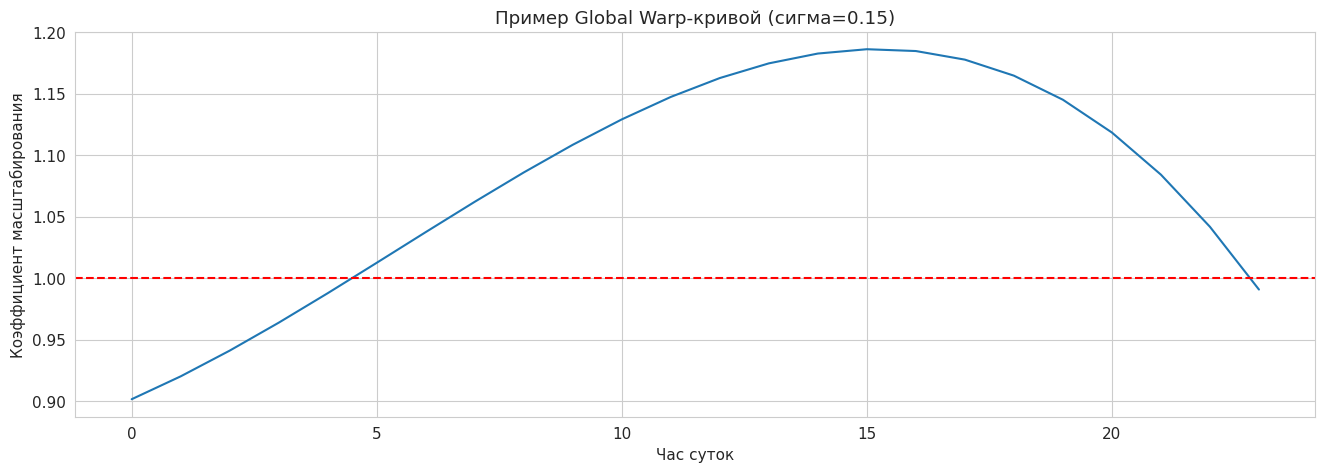

In [7]:
def generate_global_warp(n_hours=24, n_knots=4, sigma=0.15):
    """
    Генерирует гладкую кривую с помощью кубических сплайнов.
    Колеблется вокруг 1.0 (например, от 0.85 до 1.15).
    Одна кривая для всего города на сутки.
    """
    x = np.linspace(0, n_hours - 1, n_knots)
    y = np.random.normal(1.0, sigma, size=n_knots)
    cs = CubicSpline(x, y)
    return cs(np.arange(n_hours))

# Пример кривой
sample_warp = generate_global_warp()
plt.plot(sample_warp)
plt.title("Пример Global Warp-кривой (сигма=0.15)")
plt.axhline(1.0, color='red', linestyle='--')
plt.xlabel("Час суток")
plt.ylabel("Коэффициент масштабирования")
plt.show()

## 5. Генерация 60 дней синтетики (Pipeline)

In [8]:
GEN_DAYS = 60
synth_days = []

holidays = [(1, 1), (1, 2), (1, 3), (1, 4), (1, 5), (1, 6), (1, 7), (1, 8),
            (2, 23), (3, 8), (5, 1), (5, 9), (6, 12), (11, 4)]

last_real_date = pivot.index[-1]

WARP_SIGMA = 0.08 

print(f"Начало генерации с {last_real_date + pd.Timedelta(hours=1)} (сигма варпинга={WARP_SIGMA})...")
for d in range(GEN_DAYS):
    target_date = last_real_date + pd.Timedelta(days=d+1)
    target_dow = target_date.dayofweek
    is_holiday = (target_date.month, target_date.day) in holidays
    
    # ШАГ 1: Foundation (Block Bootstrapping + Holiday Logic)
    if is_holiday:
        # Если праздник: берем паттерн Воскресенья (dow=6)
        available_blocks = day_blocks.get(6, [])
        if not available_blocks:
            all_available = [b for blocks in day_blocks.values() for b in blocks]
            chosen_day = all_available[np.random.randint(len(all_available))]
        else:
            chosen_day = available_blocks[np.random.randint(len(available_blocks))]
        chosen_day = chosen_day * np.random.uniform(0.75, 0.90)
    else:
        available_blocks = day_blocks.get(target_dow, [])
        if not available_blocks:
            all_available = [b for blocks in day_blocks.values() for b in blocks]
            chosen_day = all_available[np.random.randint(len(all_available))]
        else:
            chosen_day = available_blocks[np.random.randint(len(available_blocks))]
    
    # ШАГ 2: Morphing (Global Magnitude Warping)
    warp_curve = generate_global_warp(n_hours=24, n_knots=4, sigma=WARP_SIGMA)
    warped_day = chosen_day * warp_curve[:, np.newaxis] 
    warped_day = np.maximum(warped_day, 0)
    
    # ШАГ 3: Physics (Poisson Noise)
    final_day = np.random.poisson(warped_day)
    
    synth_days.append(final_day)

synth_matrix = np.concatenate(synth_days, axis=0) # (1440, 1500)
print(f"Сгенерировано: {synth_matrix.shape[0]} часов ({synth_matrix.shape[0]/24:.0f} дней)")
print(f"Среднее: {synth_matrix.mean():.0f} пасс/час, Макс: {synth_matrix.max()}, Мин: {synth_matrix.min()}")

Начало генерации с 2025-03-17 00:00:00 (сигма варпинга=0.08)...
Сгенерировано: 1440 часов (60 дней)
Среднее: 351 пасс/час, Макс: 23354, Мин: 0


## 6. Склейка реальных и синтетических данных + Сохранение

In [9]:
objects_list = top_objects.tolist()
augmented_data = {}

for i, oid in enumerate(objects_list):
    real_7d = real_matrix[:, i]
    synth_60d = synth_matrix[:, i]
    augmented_data[oid] = np.concatenate([real_7d, synth_60d])

with open('./eda_output/augmented_data.pkl', 'wb') as f:
    pickle.dump(augmented_data, f)

total_h = len(list(augmented_data.values())[0])
print(f"Сохранено {len(augmented_data)} объектов по {total_h} часов ({total_h/24:.0f} дней)")

Сохранено 1500 объектов по 1608 часов (67 дней)


In [15]:
len(augmented_data)

1500

## 7. Визуальная проверка амплитуды

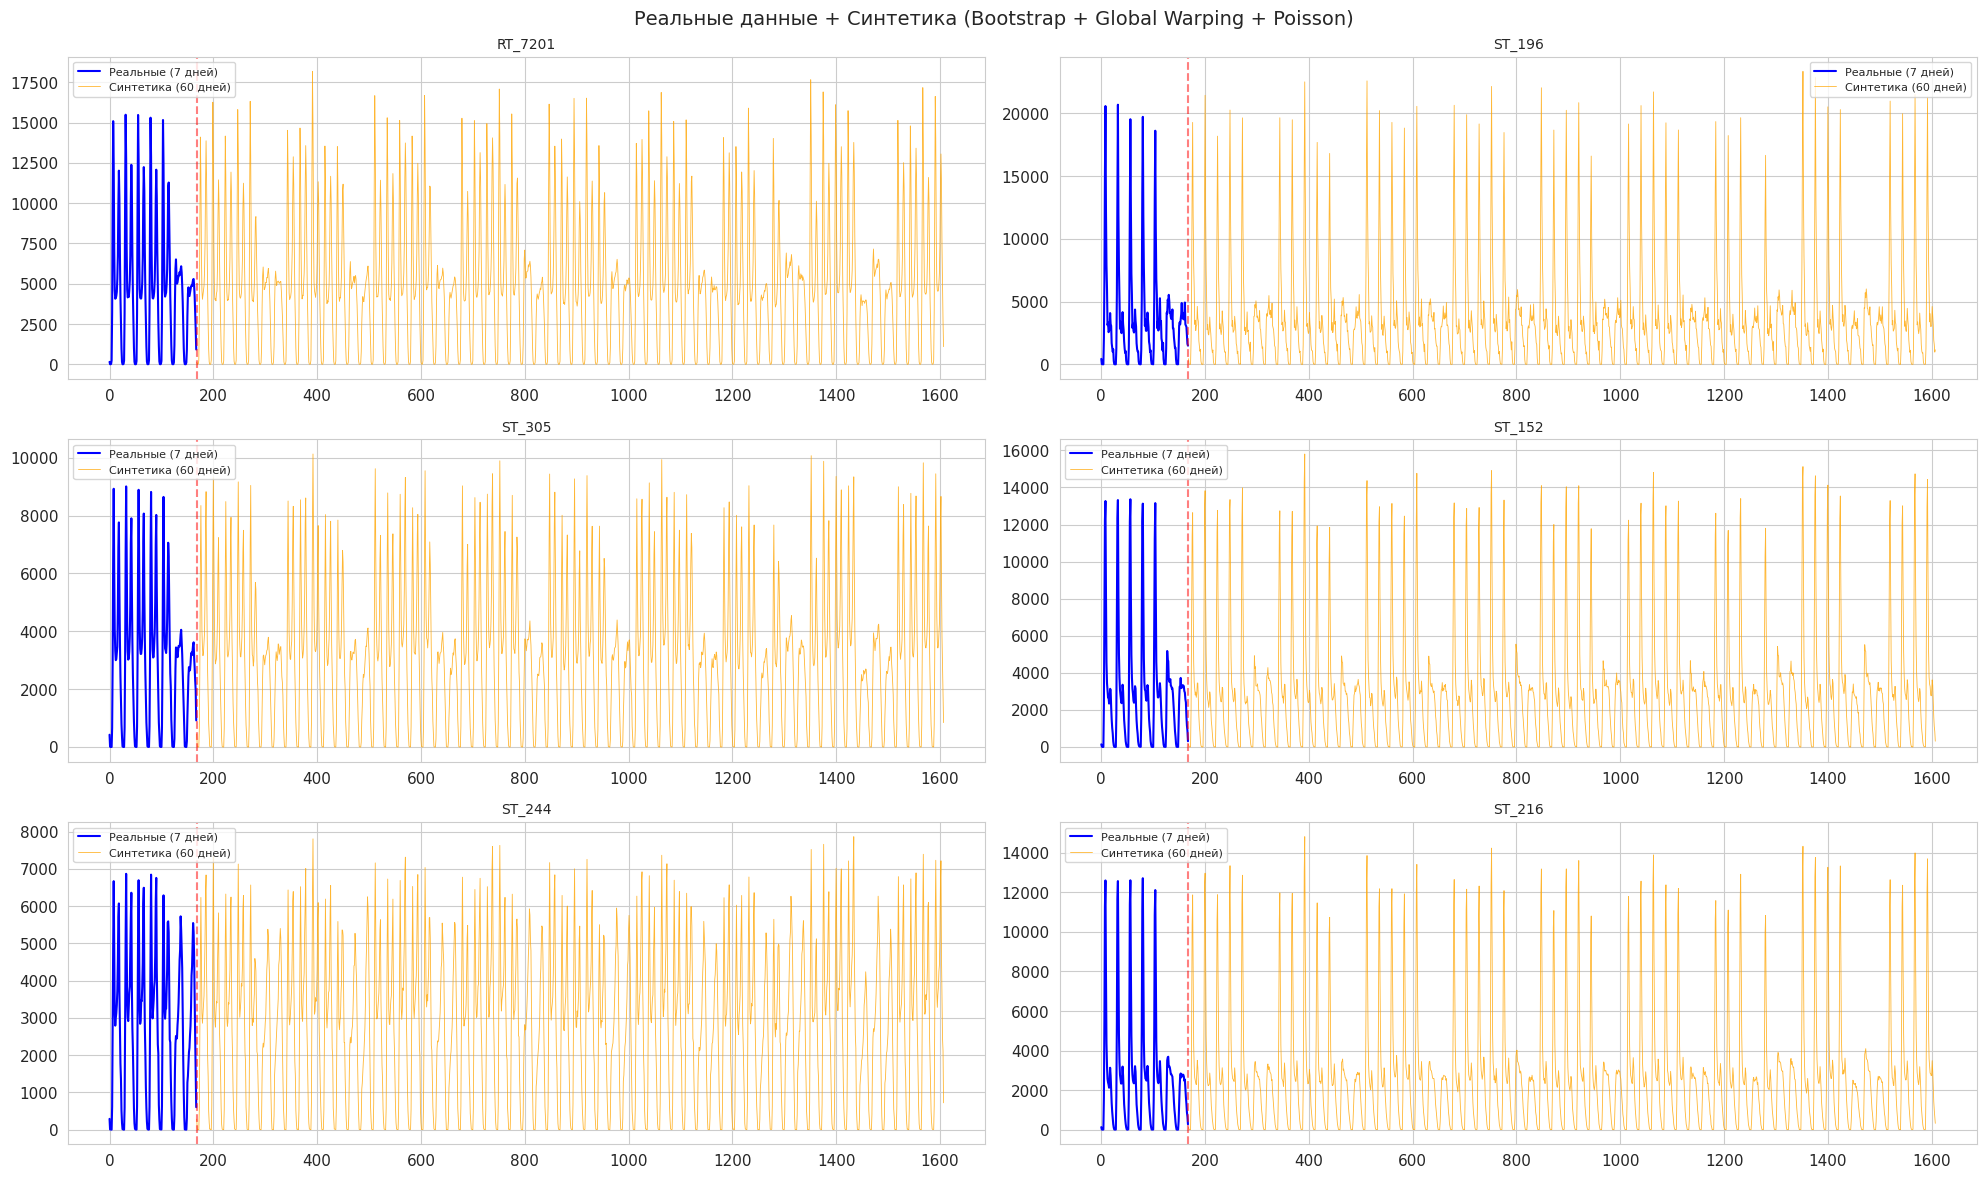

In [10]:
fig, axes = plt.subplots(3, 2, figsize=(20, 12))
axes = axes.ravel()

top6 = pivot.sum().nlargest(6).index
for idx, oid in enumerate(top6):
    ax = axes[idx]
    data = augmented_data[oid]
    real_h = 168 # 7 дней
    
    ax.plot(range(real_h), data[:real_h], color='blue', lw=1.5, label='Реальные (7 дней)')
    ax.plot(range(real_h, len(data)), data[real_h:], color='orange', lw=0.6, alpha=0.8, label='Синтетика (60 дней)')
    ax.axvline(real_h, color='red', ls='--', alpha=0.5)
    ax.set_title(f"{oid}", fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Реальные данные + Синтетика (Bootstrap + Global Warping + Poisson)', fontsize=14)
plt.tight_layout()
plt.savefig('./eda_output/hybrid_augmentation.png', dpi=150)
plt.show()

## 8. Проверка пространственной корреляции (Для GAT)

In [12]:
# Сравниваем корреляцию реальных 7 дней и первых 7 дней синтетики
corr_real = np.corrcoef(real_matrix.T)
corr_synth = np.corrcoef(synth_matrix[:168, :].T)

mask = ~np.eye(corr_real.shape[0], dtype=bool)
avg_corr_real = corr_real[mask].mean()
avg_corr_synth = corr_synth[mask].mean()

print(f"Средняя кросс-корреляция станций (пространственный граф):")
print(f"  Реальные (7 дней):     {avg_corr_real:.3f}")
print(f"  Синтетика (первые 7д): {avg_corr_synth:.3f}")
print(f"  Разница:                {abs(avg_corr_real - avg_corr_synth):.3f}")

if abs(avg_corr_real - avg_corr_synth) < 0.05:
    print("Корреляция сохранена")
else:
    print("Корреляция сильно изменилась.")

Средняя кросс-корреляция станций (пространственный граф):
  Реальные (7 дней):     0.719
  Синтетика (первые 7д): 0.708
  Разница:                0.011
Корреляция сохранена
